In [21]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [22]:
import cv2
import random
import matplotlib.pyplot as plt
import seaborn as sb
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import LabelEncoder, StandardScaler

In [23]:
clahe=cv2.createCLAHE(clipLimit=2.0,tileGridSize=(8,8))
def pp_image(img_path):
    img=cv2.imread(img_path)
    if img is None:
        return None
    img=cv2.resize(img,(64,64),interpolation=cv2.INTER_AREA)
    img=cv2.bilateralFilter(img,d=7,sigmaColor=50,sigmaSpace=50)
    img=cv2.cvtColor(img,cv2.COLOR_BGR2YCrCb)
    img[:,:,0]=clahe.apply(img[:,:,0])
    img=cv2.cvtColor(img,cv2.COLOR_YCrCb2BGR)
    return img

In [24]:
data_path="/kaggle/input/datasets/strangexe/education-dataset/Education"
images=[]
labels=[]
skipped=0
for label in sorted(os.listdir(data_path)):
    class_path=os.path.join(data_path,label)
    if not os.path.isdir(class_path):
        continue
    all_imgs=[f for f in os.listdir(class_path) if f.lower().endswith('.jpg')]
    sampled=random.sample(all_imgs,min(300,len(all_imgs)))
    count=0
    for img_name in sampled:
        img=pp_image(os.path.join(class_path,img_name))
        if img is None:
            skipped+=1
            continue
        images.append(img)
        labels.append(label)
        count+=1
    print(f"{label}: {count} images loaded")
images=np.array(images)
labels=np.array(labels)
print(f"\n{'-'*40}")
print(f"Total images loaded: {len(images)}")
print(f"Skipped (unreadable): {skipped}")
print(f"Images shape: {images.shape}")
print(f"Classes: {np.unique(labels)}")

Answering questions: 153 images loaded
Discussion: 150 images loaded
Guidance _ coaching: 153 images loaded
Lecturing: 151 images loaded
Listening to lecture: 157 images loaded
Reading aloud: 149 images loaded
Reading and writing: 153 images loaded
SCB5-Discuss-2024-9-17_images_train: 300 images loaded
SCB5-Discuss-2024-9-17_images_val: 300 images loaded
SCB5-Handrise-Read-write-2024-9-17_images_train: 300 images loaded
SCB5-Handrise-Read-write-2024-9-17_images_val: 300 images loaded
SCB5_Teacher_Behavior_Stand_BlackBoard_Sreen_20250406-2_images_train: 300 images loaded
SCB5_Teacher_Behavior_Stand_BlackBoard_Sreen_20250406-2_images_val: 300 images loaded
SCB_BowTurnHead_20250509_SCB5-Turn-Bow-Head-2024-9-17_images_train: 300 images loaded
SCB_BowTurnHead_20250509_SCB5-Turn-Bow-Head-2024-9-17_images_val: 300 images loaded
Stage demonstration: 59 images loaded
Stage interaction: 300 images loaded
Student at blackboard: 300 images loaded
Student hand-raise: 300 images loaded
Teacher at bl

In [25]:
X=images.astype(np.float32)/255.0
X=X.reshape(X.shape[0],-1)

In [27]:
le=LabelEncoder()
y=le.fit_transform(labels)

In [28]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)

In [29]:
scaler=StandardScaler()
X_train=scaler.fit_transform(X_train)
X_test=scaler.transform(X_test)

In [30]:
model=LogisticRegression(max_iter=1000,solver='lbfgs',class_weight='balanced',C=1.0,multi_class='multinomial')

In [31]:
model.fit(X_train,y_train)
predictions=model.predict(X_test)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


In [32]:
print(f"Accuracy: {accuracy_score(y_test,predictions):.4f}")
print(f"Micro F1: {f1_score(y_test,predictions,average='micro'):.4f}")
print(f"Macro F1: {f1_score(y_test,predictions,average='macro'):.4f}")
print(f"Weighted F1: {f1_score(y_test,predictions,average='weighted'):.4f}")

Accuracy: 0.3221
Micro F1: 0.3221
Macro F1: 0.3191
Weighted F1: 0.3235


In [33]:
print(classification_report(y_test,predictions,target_names=le.classes_))

                                                                      precision    recall  f1-score   support

                                                 Answering questions       0.28      0.30      0.29        30
                                                          Discussion       0.03      0.03      0.03        30
                                                 Guidance _ coaching       0.10      0.06      0.08        31
                                                           Lecturing       0.13      0.13      0.13        30
                                                Listening to lecture       0.26      0.19      0.22        31
                                                       Reading aloud       0.46      0.43      0.45        30
                                                 Reading and writing       0.34      0.35      0.35        31
                                 SCB5-Discuss-2024-9-17_images_train       0.26      0.30      0.28        60
         

In [35]:
cm=confusion_matrix(y_test,predictions)
print(cm)

[[ 9  0  0  1  2  2  1  0  1  3  2  0  1  1  1  0  0  0  3  0  1  2]
 [ 0  1  1  0  0  0  0  9  5  3  1  1  3  2  1  0  0  0  0  0  3  0]
 [ 0  2  2  0  0  1  0  9  2  0  3  1  4  2  0  0  2  0  0  0  1  2]
 [ 0  1  0  4  0  0  0  0  0  2  0  4  4  1  0  0  2  0  4  7  0  1]
 [ 1  1  0  3  6  2  0  0  0  2  0  1  4  2  0  0  0  1  2  0  3  3]
 [ 1  0  0  0  1 13  1  0  0  1  3  1  0  2  1  0  0  1  4  0  0  1]
 [ 0  1  0  0  0  1 11  1  0  1  1  1  3  2  1  0  0  0  1  2  1  4]
 [ 2  8  3  0  0  0  0 18  0  6  3  5  9  3  1  0  0  0  0  0  0  2]
 [ 0  9  0  0  0  0  1  1 40  1  1  1  1  1  1  0  1  1  1  0  0  0]
 [ 2  1  2  0  1  1  3  2  1  5  4  9  7  6  3  0  3  1  3  2  3  1]
 [ 2  3  1  3  1  1  1  3  1  3 13  5  5  6  0  0  0  1  2  0  4  5]
 [ 1  0  3  2  0  2  1  5  1  3  6  4  4  7  0  0  5  0  2  3  7  4]
 [ 4  1  0  4  3  1  0  2  0  3  3  4  6  6  3  0  3  3  2  5  4  3]
 [ 1  1  1  0  0  0  4  4  1  7  5  6  5 11  0  0  2  1  1  4  4  2]
 [ 1  0  2  1  0  1  0  6  1  1  1

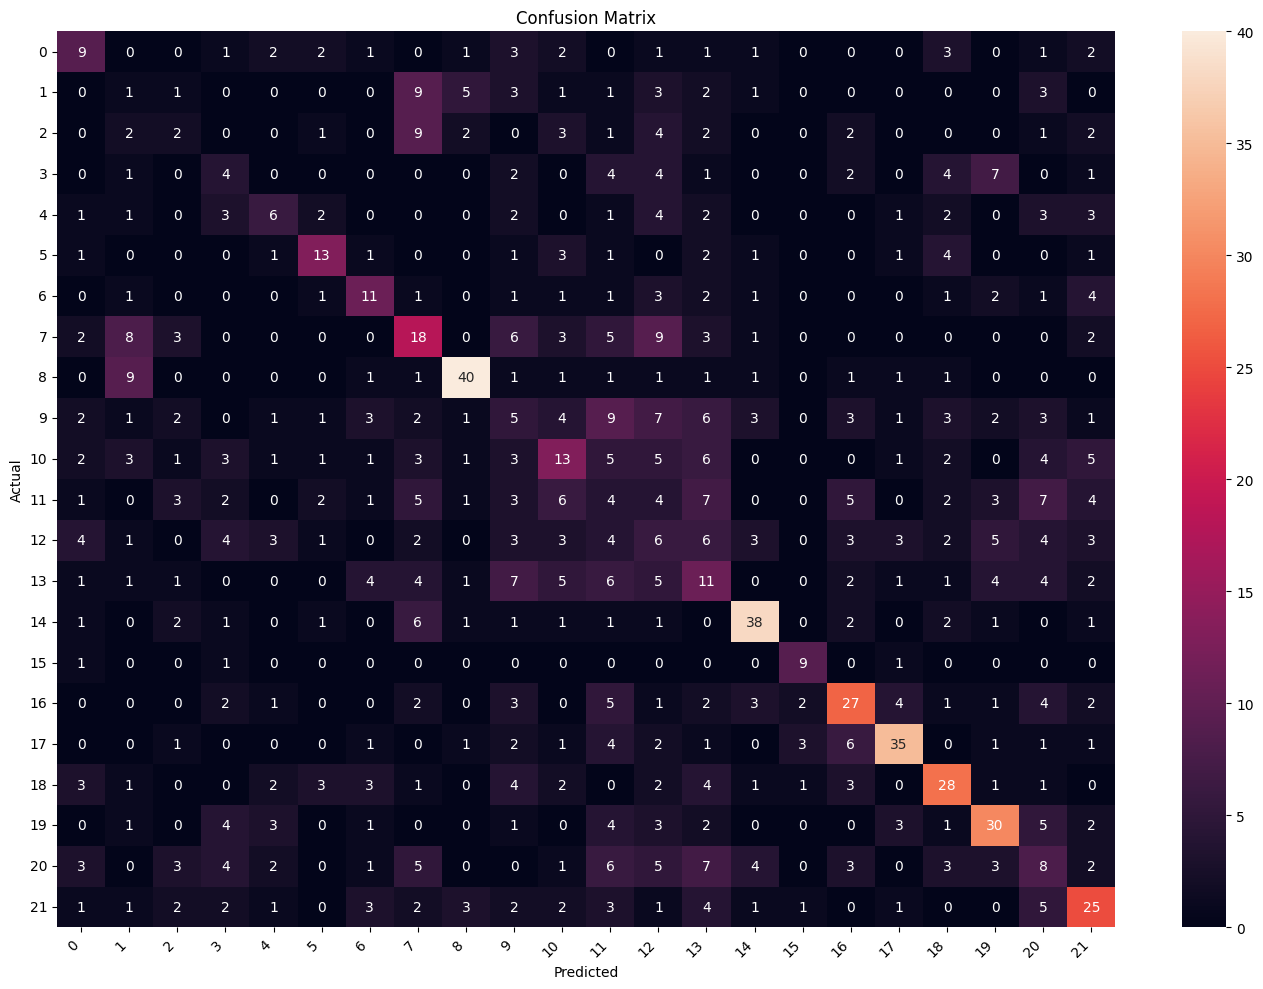

In [38]:
plt.figure(figsize=(14,10))
sb.heatmap(cm,annot=True)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.xticks(rotation=45,ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

------

# UI

----

In [37]:
ui_in=input("Enter path of image to test: ")
img=pp_image(ui_in)
if img is None:
    print("Invalid path:",ui_in)
else:
    ui_X=img.astype(np.float32)/255.0
    ui_X=ui_X.reshape(1,-1)
    ui_X=scaler.transform(ui_X)
    pred=model.predict(ui_X)[0]
    print("Prediction:",le.inverse_transform([pred])[0])

Enter path of image to test:  /kaggle/input/datasets/strangexe/education-dataset/Education/Discussion/._1.jpg


Invalid path: /kaggle/input/datasets/strangexe/education-dataset/Education/Discussion/._1.jpg
